In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from concept_abstraction.plotting import *
from concept_abstraction.utils import *

In [3]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

In [4]:
style_size = 'paper'

## Real World Environments

### Training Time

In [5]:
training_times = [5000,10000,15000,20000]
environments = ["cart_pole","cart_pole_binary"]
total_time = [[[] for i in range(len(training_times))] for j in range(len(environments))]
random_selection = [[[] for i in range(len(training_times))] for j in range(len(environments))]
greedy_selection = [[[] for i in range(len(training_times))] for j in range(len(environments))]

baseline_params = {'environment_string': 'cart_pole_binary', 'num_concepts_selected': 4, 'seed': 42, 'selection_function': 'policy', 'reward_error': 0, 'training_timesteps': training_times[-2]}
for idx,env in enumerate(environments):
    for jdx,t in enumerate(training_times):
        baseline_params['environment_string'] = env 
        baseline_params['training_timesteps'] = t
        results = get_results_matching_parameters("cart_pole","",baseline_params)
        total_time[idx][jdx] = results[0]['greedy_selection']['time']
        random_selection[idx][jdx] = results[0]['random_selection']['values']
        greedy_selection[idx][jdx] = results[0]['greedy_selection']['values']

total_time = np.array(total_time)
random_selection = np.array(random_selection)
greedy_selection = np.array(greedy_selection)

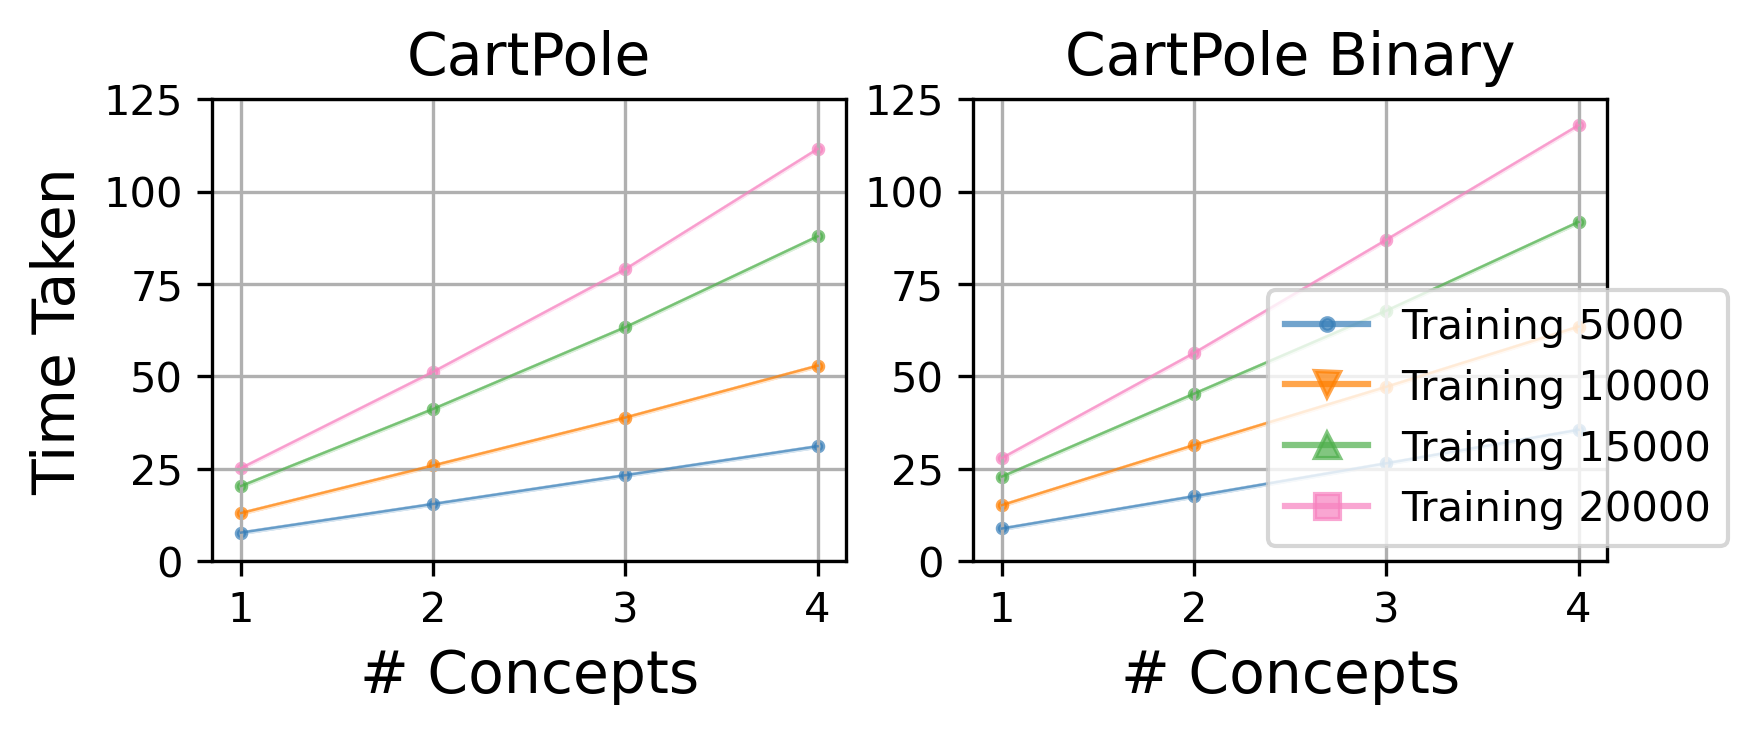

In [6]:
plot_dimensions = (1,2)
x_labels = [["# Concepts","# Concepts"]]
y_labels = [["Time Taken",""]]
titles = [["CartPole","CartPole Binary"]]
sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2,3],[1,2,3,4]],[[0,1,2,3],[1,2,3,4]]]],
    'has_grid': True, 
    'y_lim': [[[0,125],[0,125]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

for idx,env in enumerate(environments):
    all_x_groups = []
    all_lines = []
    all_labels = []

    for jdx,t in enumerate(training_times):
        all_x_groups.append(list(range(4)))
        all_lines.append(total_time[idx][jdx])
        all_labels.append("Training {}".format(t))
        
    plot_line(ax[0][idx],all_x_groups,all_lines,[[0 for i in range(len(arr))] for arr in all_lines],all_labels,line_format)

    scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

    plot_scatter(ax[0][idx],all_x_groups,all_lines,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/cart_pole_time.pdf",dpi=300, bbox_inches='tight')

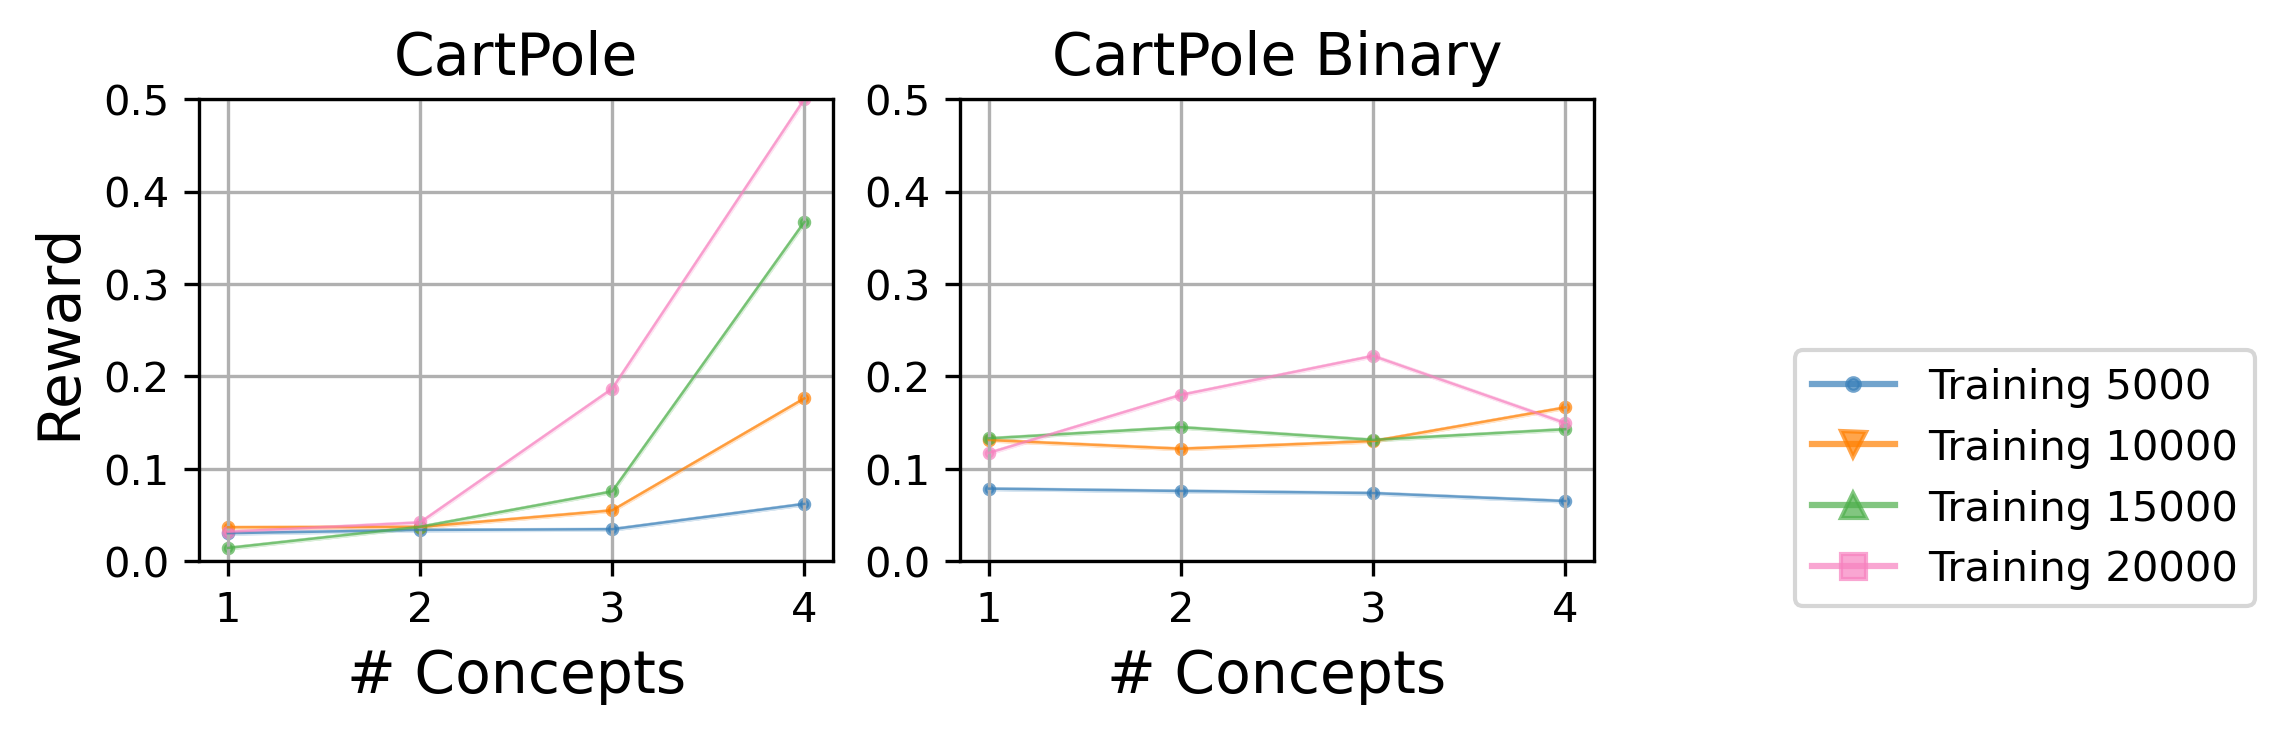

In [7]:
plot_dimensions = (1,2)
x_labels = [["# Concepts","# Concepts"]]
y_labels = [["Reward",""]]
titles = [["CartPole","CartPole Binary"]]
sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2,3],[1,2,3,4]],[[0,1,2,3],[1,2,3,4]]]],
    'has_grid': True, 
    'y_lim': [[[0,0.5],[0,0.5]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

for idx,env in enumerate(environments):
    all_x_groups = []
    all_lines = []
    all_labels = []

    for jdx,t in enumerate(training_times):
        all_x_groups.append(list(range(4)))
        all_lines.append(greedy_selection[idx][jdx])
        all_labels.append("Training {}".format(t))
        
    plot_line(ax[0][idx],all_x_groups,all_lines,[[0 for i in range(len(arr))] for arr in all_lines],all_labels,line_format)

    scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

    plot_scatter(ax[0][idx],all_x_groups,all_lines,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (1,0), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/cart_pole_reward.pdf",dpi=300, bbox_inches='tight')

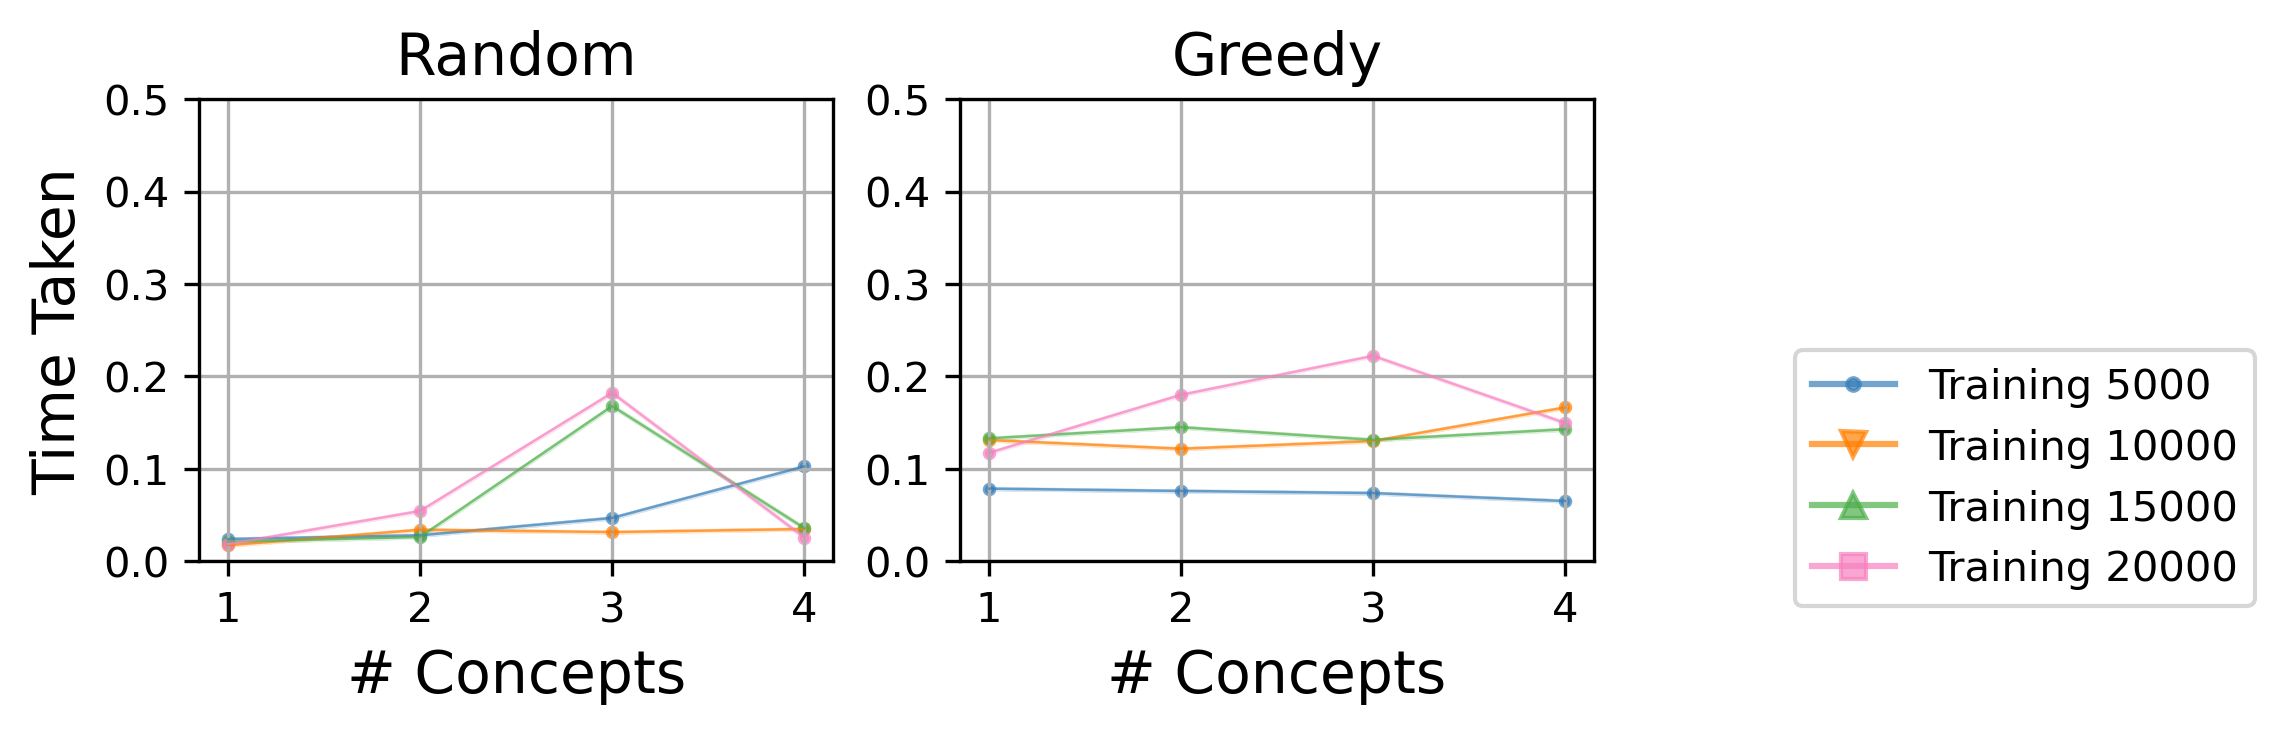

In [8]:
plot_dimensions = (1,2)
x_labels = [["# Concepts","# Concepts"]]
y_labels = [["Time Taken",""]]
titles = [["Random","Greedy"]]
sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2,3],[1,2,3,4]],[[0,1,2,3],[1,2,3,4]]]],
    'has_grid': True, 
    'y_lim': [[[0,0.5],[0,0.5]]]
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label,titles=titles)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

for idx,method in enumerate([random_selection,greedy_selection]):
    all_x_groups = []
    all_lines = []
    all_labels = []

    for jdx,t in enumerate(training_times):
        all_x_groups.append(list(range(4)))
        all_lines.append(method[1][jdx])
        all_labels.append("Training {}".format(t))
        
    plot_line(ax[0][idx],all_x_groups,all_lines,[[0 for i in range(len(arr))] for arr in all_lines],all_labels,line_format)

    scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

    plot_scatter(ax[0][idx],all_x_groups,all_lines,line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (1,0), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/random_greedy_cart_pole.pdf",dpi=300, bbox_inches='tight')

### Concept Definition

In [9]:
selection_methods = ["policy","q_value","transition"]
environments = ["cart_pole","cart_pole_binary","cart_pole_llm","cart_pole_post_hoc"]
greedy_selection = [[[] for i in range(len(environments))] for j in range(len(selection_methods))]

baseline_params = {'environment_string': 'cart_pole_binary', 'num_concepts_selected': 4, 'seed': 42, 'selection_function': 'policy', 'reward_error': 0, 'training_timesteps': 10000}
for idx,method in enumerate(selection_methods):
    for jdx,env in enumerate(environments):
        baseline_params['environment_string'] = env 
        baseline_params['selection_function'] = method
        results = get_results_matching_parameters("cart_pole","",baseline_params)
        greedy_selection[idx][jdx] = results[0]['greedy_selection']['values']
greedy_selection = np.array(greedy_selection)

4 six_color 3
4 six_color 3
4 six_color 3
4 six_color 3


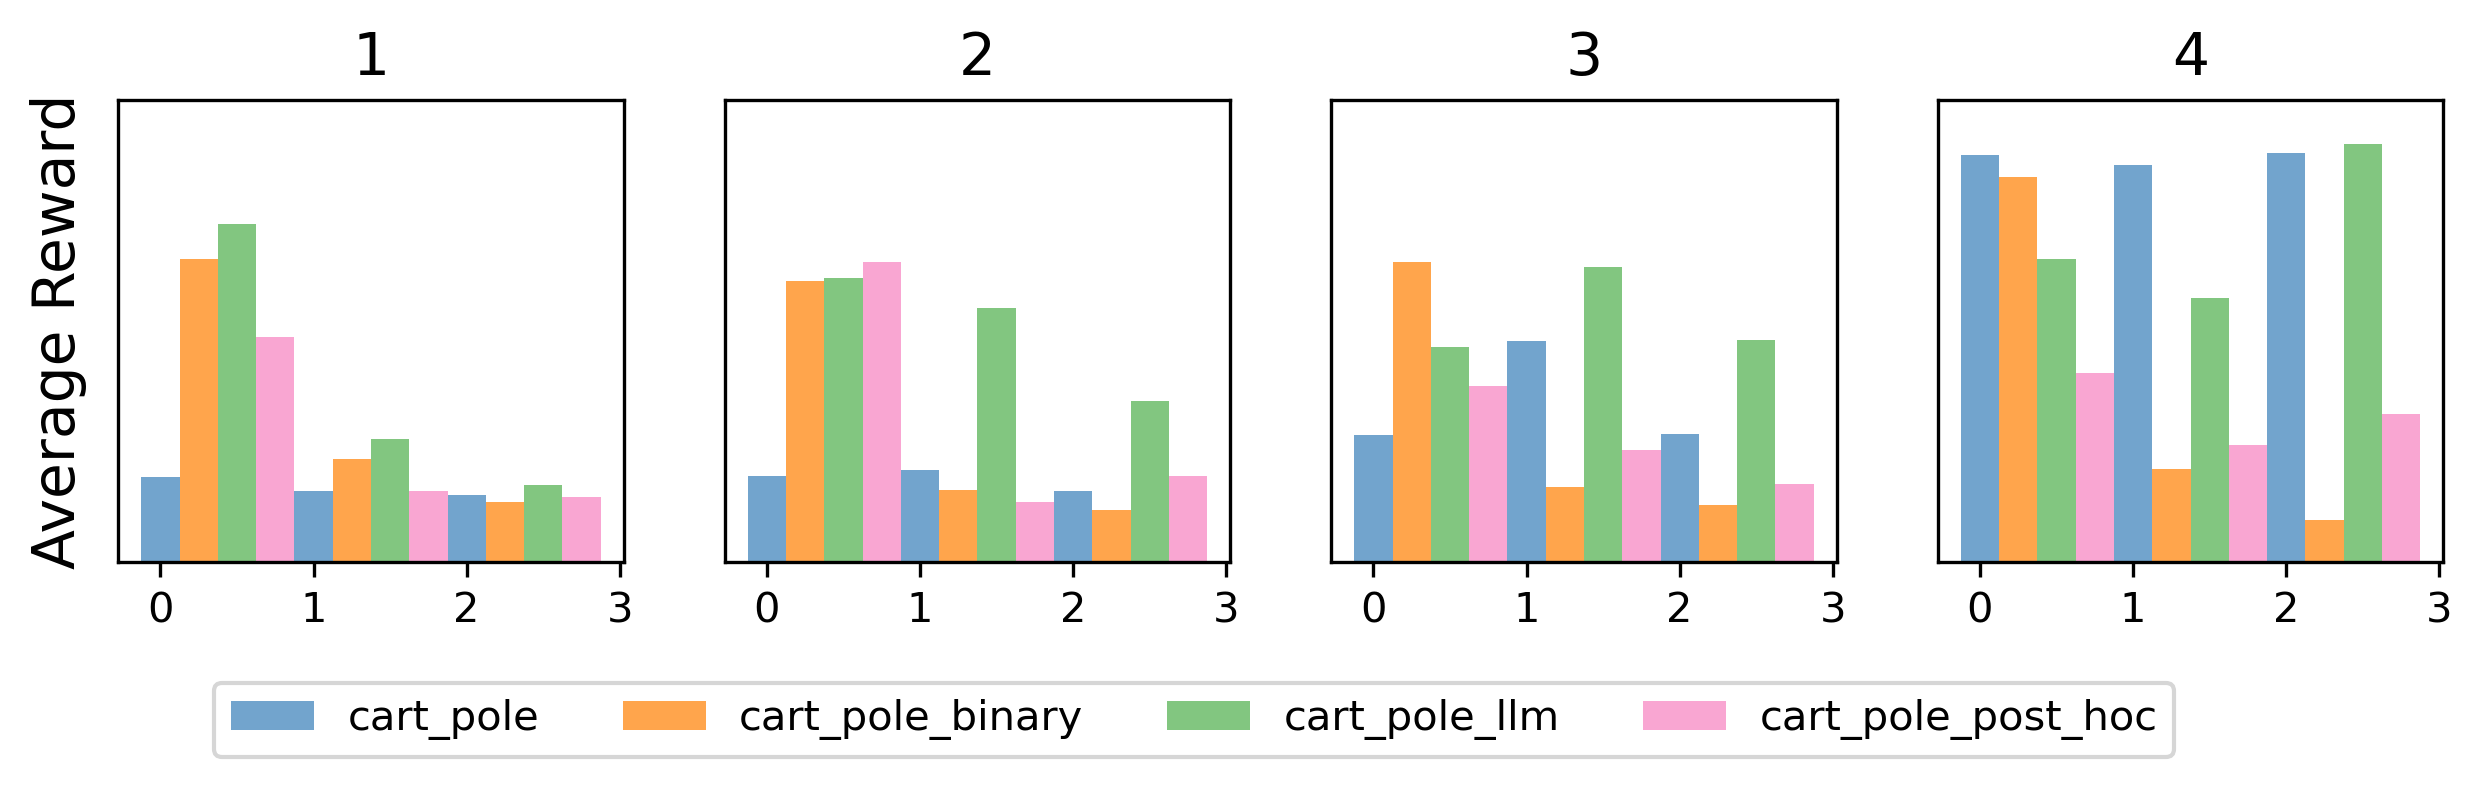

In [10]:
plot_dimensions = (1,4)
titles = [["1","2","3","4"]]
y_labels = [["Average Reward","","",""]]
sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'y_lim': [[[0,0.2] for i in range(4)]],
    'y_ticks': [[[[],[]] for i in range(4)]],
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,y_labels=y_labels,titles=titles,sup_y_label=sup_y_label)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}

for i in range(4):
    x_groups = []
    y_values = []
    for j in range(len(selection_methods)):
        x_groups += list(range(len(environments)))
        y_values += list(greedy_selection[j,:,i])
    d = {}
    for idx,env in enumerate(environments):
        d[idx] = env
    plot_bar(ax[0][i],x_groups,y_values,[0 for i in range(len(y_values))], d,bar_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 4, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/method_env_reward_cart_pole.pdf",dpi=300, bbox_inches='tight')

### Human Accuracy

In [11]:
fixed_accuracies = [0.1,0.25,0.5,0.75,0.9,0.99]
greedy_selection = [0 for i in range(len(fixed_accuracies))]

baseline_params = {'environment_string': 'cart_pole_binary', 
                    'num_concepts_selected': 0, 'seed': 42, 'selection_function': 'policy', 
                    'reward_error': 0, 'training_timesteps': 10000,'target_abstraction': 0.05,
                    'human_accuracy_by_concept': None}
for i in range(len(fixed_accuracies)):
    baseline_params['cbm_accuracy_by_concept'] = [fixed_accuracies[i] for j in range(16)]
    results = get_results_matching_parameters("cart_pole","",baseline_params)
    greedy_selection[i] = results[0]['uncertainty']['combined_value']
greedy_selection = np.array(greedy_selection)

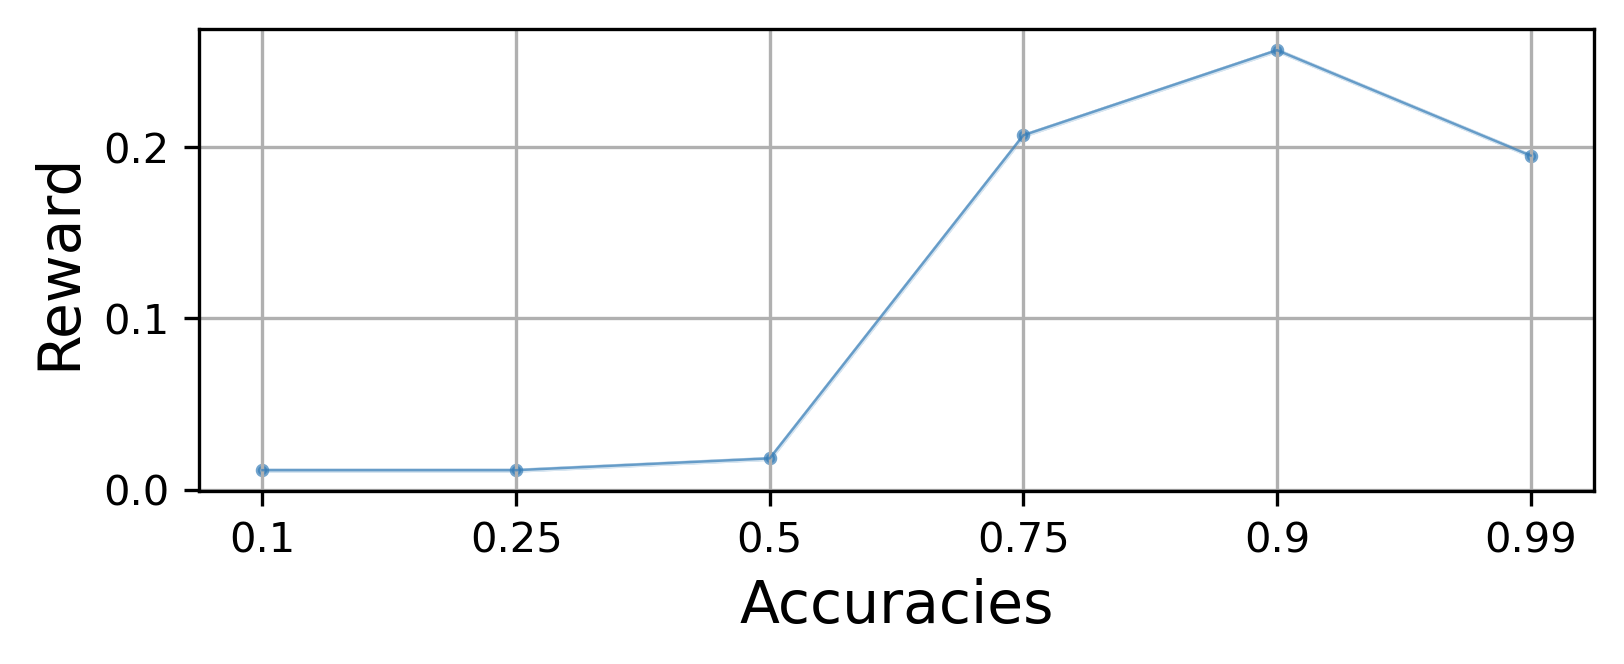

In [12]:
plot_dimensions = (1,1)
x_labels = [["Accuracies"]]
y_labels = [["Reward"]]
sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(fixed_accuracies))),fixed_accuracies]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

all_x_groups = [list(range(len(fixed_accuracies)))]
all_lines = [greedy_selection]
all_labels = [""]
    
plot_line(ax[0][0],all_x_groups,all_lines,[[0 for i in range(len(arr))] for arr in all_lines],all_labels,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],all_x_groups,all_lines,line_format)

fig.savefig("../../results/figures/reward_accuracies_cart_pole.pdf",dpi=300, bbox_inches='tight')

In [13]:
target_abstraction = [0.01,0.05,0.1,0.2]
greedy_selection = [0 for i in range(len(target_abstraction))]

baseline_params = {'environment_string': 'cart_pole_binary', 
                    'num_concepts_selected': 0, 'seed': 42, 'selection_function': 'q_value', 
                    'reward_error': 0, 'training_timesteps': 10000,
                    'cbm_accuracy_by_concept': [0.75 for j in range(16)],
                    'human_accuracy_by_concept': None}
for i in range(len(target_abstraction)):
    baseline_params['target_abstraction'] = target_abstraction[i]
    results = get_results_matching_parameters("cart_pole","",baseline_params)
    greedy_selection[i] = results[0]['uncertainty']['combined_value']
greedy_selection = np.array(greedy_selection)

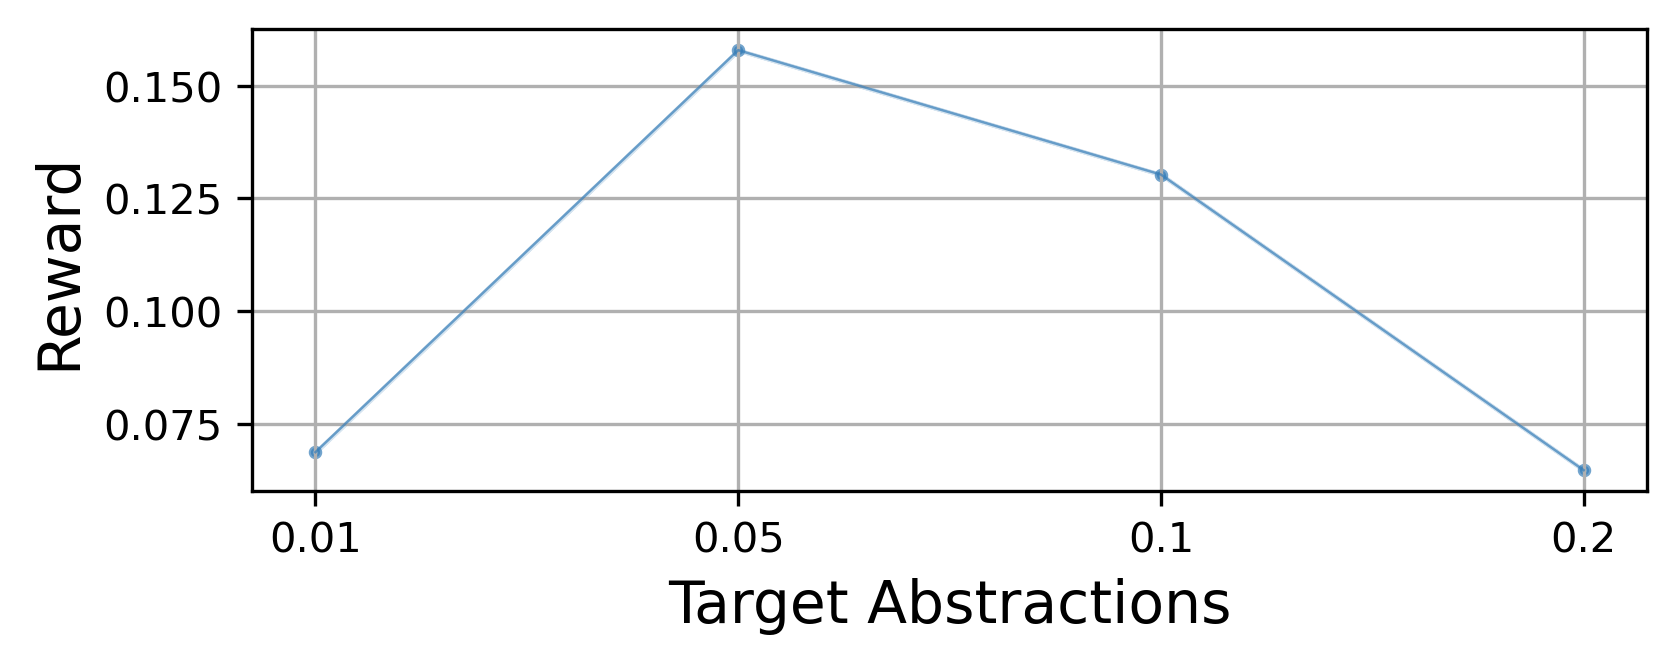

In [14]:
plot_dimensions = (1,1)
x_labels = [["Target Abstractions"]]
y_labels = [["Reward"]]
sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(target_abstraction))),target_abstraction]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

all_x_groups = [list(range(len(target_abstraction)))]
all_lines = [greedy_selection]
all_labels = [""]
    
plot_line(ax[0][0],all_x_groups,all_lines,[[0 for i in range(len(arr))] for arr in all_lines],all_labels,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],all_x_groups,all_lines,line_format)

fig.savefig("../../results/figures/reward_abstraction_cart_pole.pdf",dpi=300, bbox_inches='tight')

In [15]:
human_rel = [0.1,0.25,0.5,0.75,0.9]
greedy_selection = [0 for i in range(len(human_rel))]

baseline_params = {'environment_string': 'cart_pole_binary', 
                    'num_concepts_selected': 0, 'seed': 42, 'selection_function': 'policy', 
                    'reward_error': 0, 'training_timesteps': 10000,
                    'cbm_accuracy_by_concept': [0.5 for j in range(16)],
                    'human_accuracy_by_concept': [0.9 for j in range(16)]}
for i in range(len(human_rel)):
    baseline_params['human_reliance_by_concept'] = [human_rel[i] for j in range(16)]
    results = get_results_matching_parameters("cart_pole","",baseline_params)
    greedy_selection[i] = results[0]['uncertainty']['combined_value']
greedy_selection = np.array(greedy_selection)

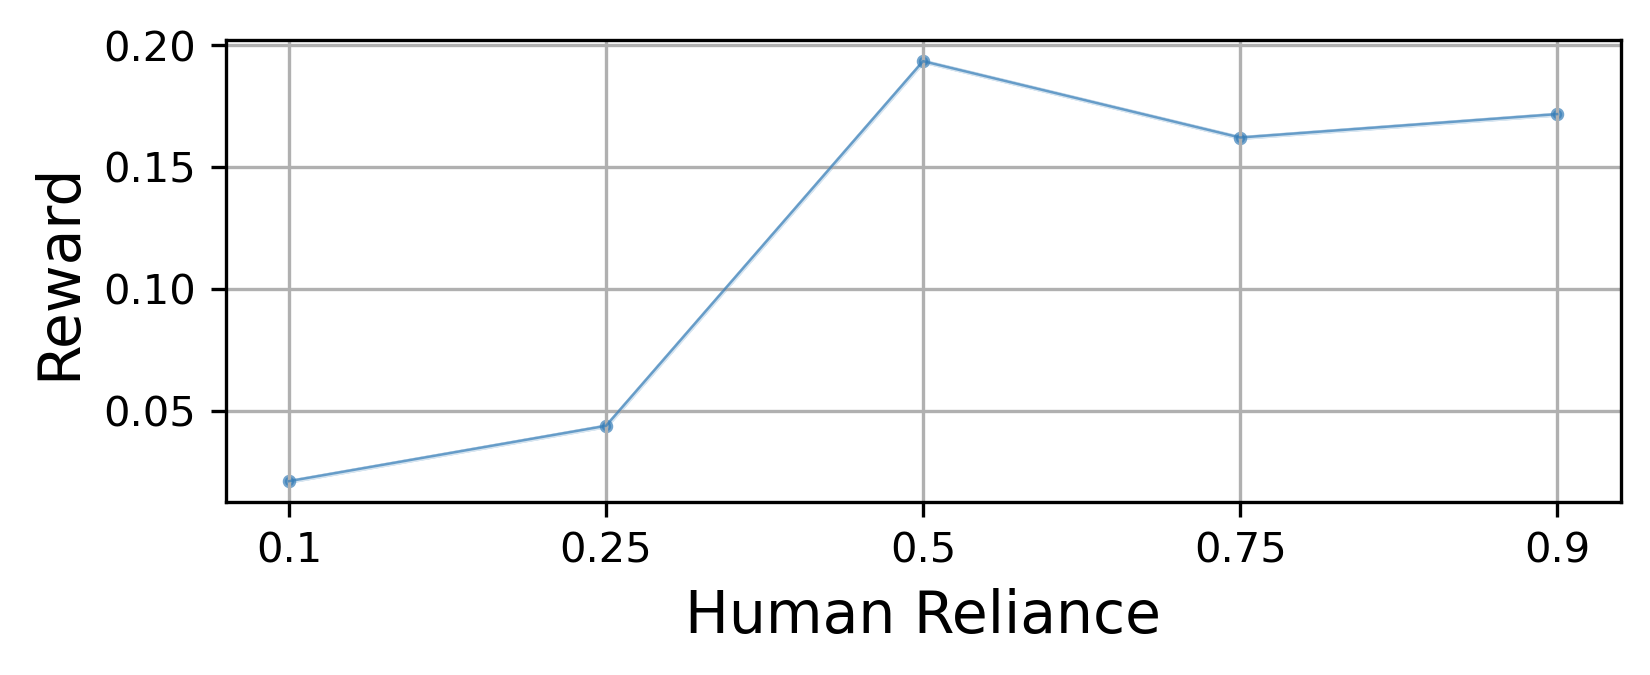

In [16]:
plot_dimensions = (1,1)
x_labels = [["Human Reliance"]]
y_labels = [["Reward"]]
sup_y_label = ""
overall_format = {'figsize':(6,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(human_rel))),human_rel]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

all_x_groups = [list(range(len(human_rel)))]
all_lines = [greedy_selection]
all_labels = [""]
    
plot_line(ax[0][0],all_x_groups,all_lines,[[0 for i in range(len(arr))] for arr in all_lines],all_labels,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],all_x_groups,all_lines,line_format)

fig.savefig("../../results/figures/reward_reliance_cart_pole.pdf",dpi=300, bbox_inches='tight')

In [17]:
reward_errors = [0.1,0.25,0.5,0.75,1]
env_list = ["cart_pole", "cart_pole_binary","cart_pole_llm","cart_pole_post_hoc"]
greedy_selection = [[[0 for i in range(4)] for i in range(len(env_list))] for i in range(len(reward_errors))]

baseline_params = {'num_concepts_selected': 4, 'seed': 42, 'selection_function': 'policy',
                    'training_timesteps': 10000}
for i in range(len(reward_errors)):
    for j,env in enumerate(env_list):
        baseline_params['environment_string'] = env_list[j]
        baseline_params['reward_error'] = reward_errors[i]
        results = get_results_matching_parameters("cart_pole","",baseline_params)
        greedy_selection[i][j] = results[0]['greedy_selection']['values']
greedy_selection = np.array(greedy_selection)

[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]] [[0.0253 0.0279 0.0928 0.197 ]
 [0.0338 0.0347 0.0539 0.1867]
 [0.0245 0.0483 0.0705 0.1577]
 [0.0233 0.0332 0.0437 0.2164]
 [0.0298 0.0378 0.0428 0.1368]] ['error 0.1', 'error 0.25', 'error 0.5', 'error 0.75', 'error 1']
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]] [[0.089  0.2021 0.1461 0.1403]
 [0.1372 0.1218 0.1232 0.1096]
 [0.1211 0.1106 0.1076 0.1404]
 [0.1677 0.1251 0.1343 0.0799]
 [0.1358 0.1178 0.0795 0.1083]] ['error 0.1', 'error 0.25', 'error 0.5', 'error 0.75', 'error 1']
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]] [[0.1185 0.134  0.1089 0.1479]
 [0.1254 0.1162 0.1155 0.1127]
 [0.1326 0.147  0.1168 0.119 ]
 [0.0894 0.1171 0.1154 0.1343]
 [0.1183 0.1138 0.0936 0.0983]] ['error 0.1', 'error 0.25', 'error 0.5', 'error 0.75', 'error 1']
[[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 3]] [[0.1074 0.1307 0.0731 0.1103]
 [0.0911 0.104  0.0

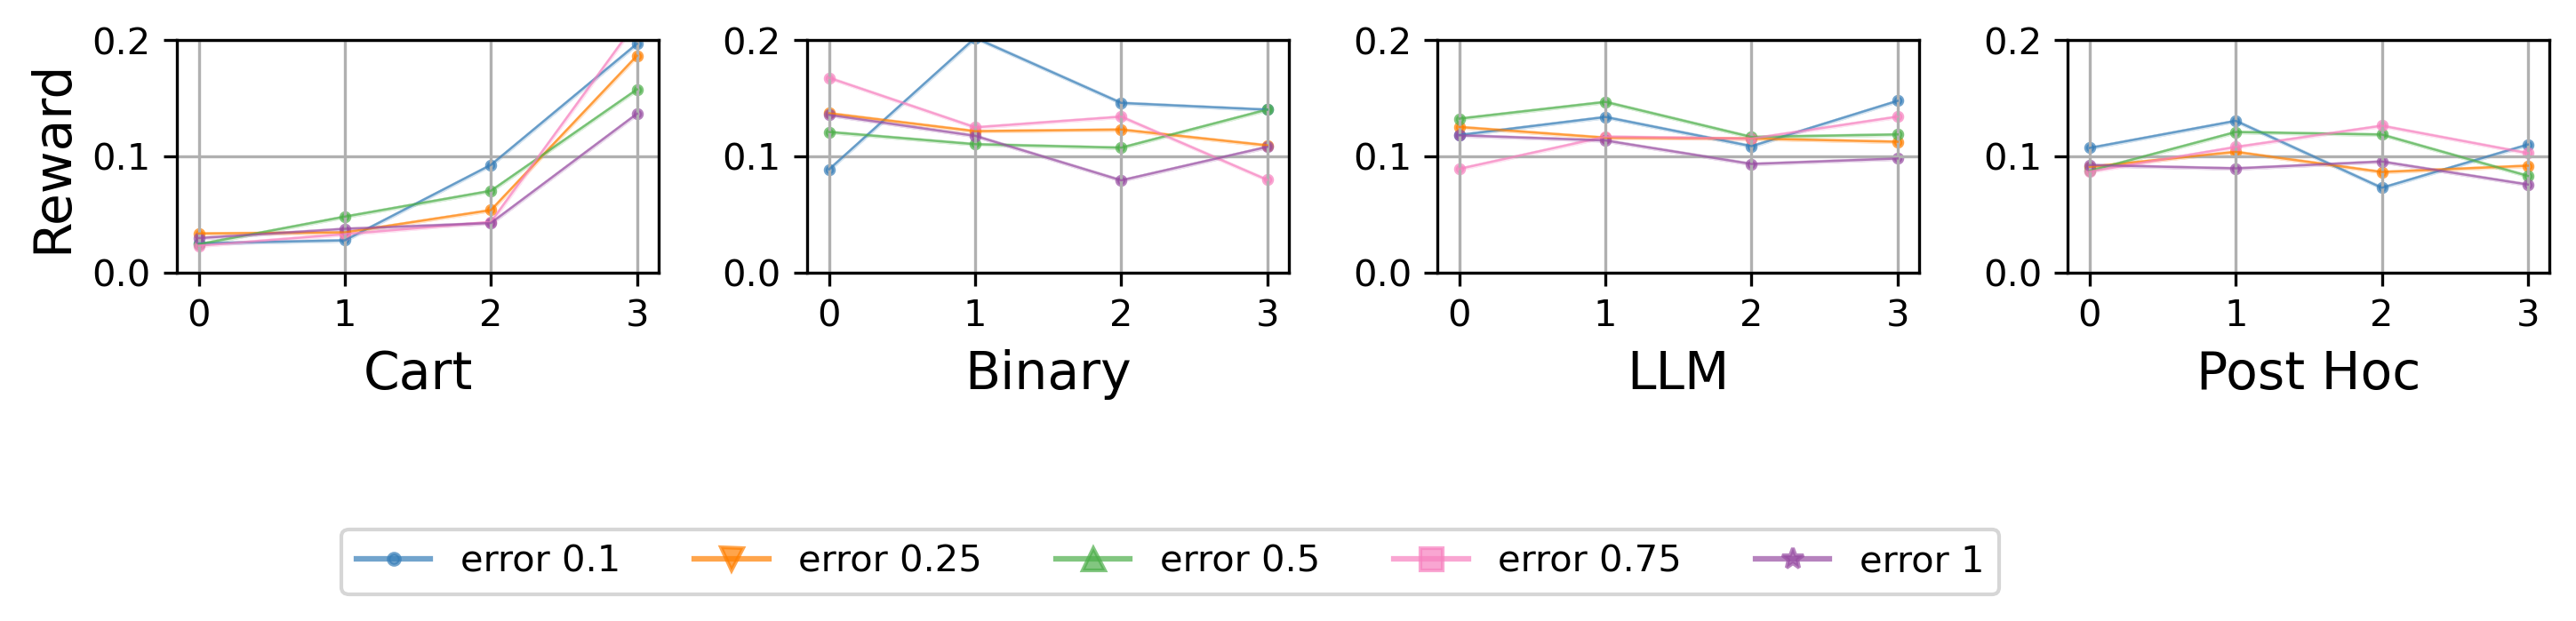

In [18]:
plot_dimensions = (1,4)
x_labels = [["Cart","Binary","LLM","Post Hoc"]]
y_labels = [["Reward","","",""]]
sup_y_label = ""
overall_format = {'figsize':(10,2),
    'style_size': style_size,
    'y_lim': [[[0,0.2] for i in range(4)]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

for i in range(len(env_list)):
    all_lines = greedy_selection[:,i,:]
    all_x_groups = [list(range(4)) for i in range(len(all_lines))]

    all_labels = ["error {}".format(i) for i in reward_errors]

    print(all_x_groups,all_lines,all_labels)
    
    plot_line(ax[0][i],all_x_groups,all_lines,[[0 for i in range(len(arr))] for arr in all_lines],all_labels,line_format)

    scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

    plot_scatter(ax[0][i],all_x_groups,all_lines,line_format)
plt.tight_layout()

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 5, 'bbox_to_anchor': (0.15,-0.25),'fontsize': 14
                , 'show_point': True}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/reward_error_cart_pole.pdf",dpi=300, bbox_inches='tight')

## Synthetic Environments

### Concept Selection

In [19]:
environment_nodes = [4,8,16]
baseline_params = {'environment_string': 'cycle', 'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
value_difference = {
    'greedy': [], 'random': [],
}
confidences_by_node = {
    'greedy': [], 'random': [],
}

for method in ['random','greedy']:
    for n in environment_nodes:
        baseline_params['environment_nodes'] = n
        results = get_results_matching_parameters("synthetic","",baseline_params)
        value_difference_local = []
        for r in results:
            baseline = np.array(r['baseline']['values'][0])

            for val in r['{}_selection'.format(method)]['values']: 
                value_difference_local.append(np.max(np.abs(np.array(val)-baseline)))
        value_difference_local = np.array(value_difference_local)
        value_difference[method].append(np.mean(value_difference_local,axis=0))
        confidences_by_node[method].append(0)


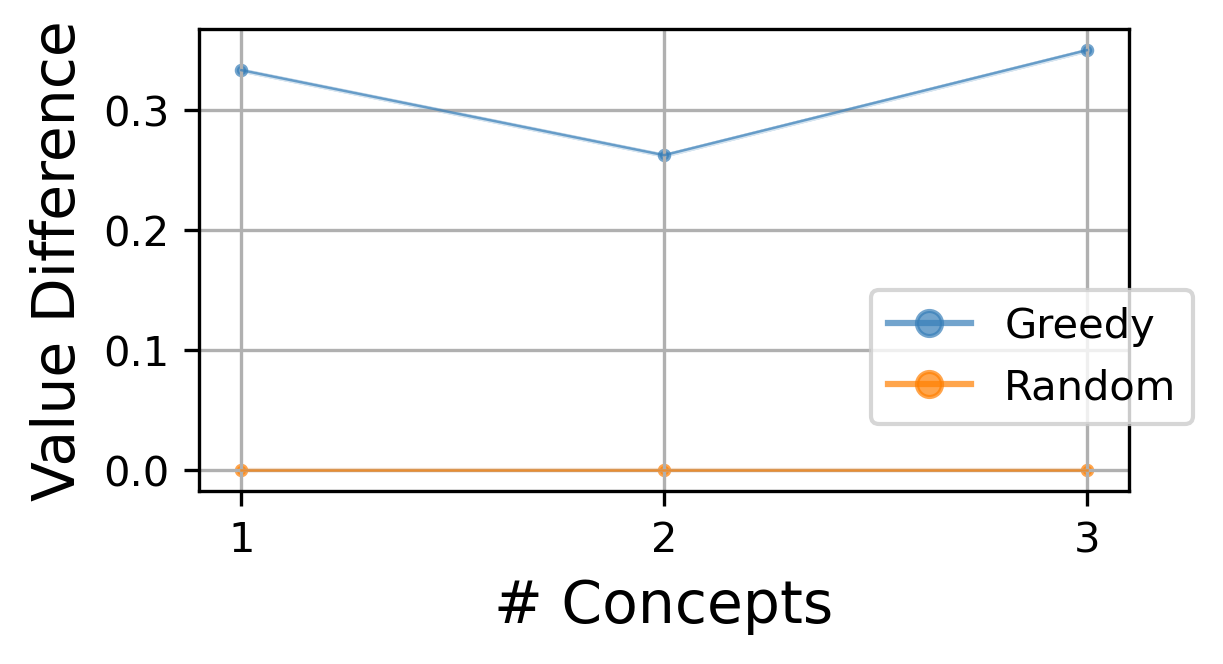

In [20]:
plot_dimensions = (1,1)
x_labels = [["# Concepts"]]
y_labels = [["Value Difference"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2],[1,2,3]]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(value_difference[method]))) for method in ['greedy','random']],[value_difference[method] for method in ['random','greedy']],[confidences_by_node[method] for method in ['greedy','random']],['Greedy','Random'],line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(value_difference[method]))) for method in ['greedy','random']],[value_difference[method] for method in ['random','greedy']],line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/value_differences_cycle.pdf",dpi=300, bbox_inches='tight')

In [21]:
environment_nodes = [3,7,15,31,63,127]
baseline_params = {'environment_string': 'tree', 'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42, 'reward_error': 0, 'transition_error': 0}
value_difference  = {
    'greedy': [], 'random': [],
}

confidences_by_node = {
    'greedy': [], 'random': [],
}

for method in ['random','greedy']:
    for n in environment_nodes:
        baseline_params['environment_nodes'] = n
        results = get_results_matching_parameters("synthetic","",baseline_params)
        value_difference_local = []
        for r in results:
            baseline = np.array(r['baseline']['values'][0])
            temp = []
            for num_selections in range(len(r['{}_selection'.format(method)]['values'])):
                temp.append(np.max(np.abs(np.array(r['{}_selection'.format(method)]['values'][num_selections])-baseline)))
            value_difference_local.append(temp)
        value_difference_local = np.array(value_difference_local)
        value_difference[method].append(np.mean(value_difference_local,axis=0))
        confidences_by_node[method].append(0)


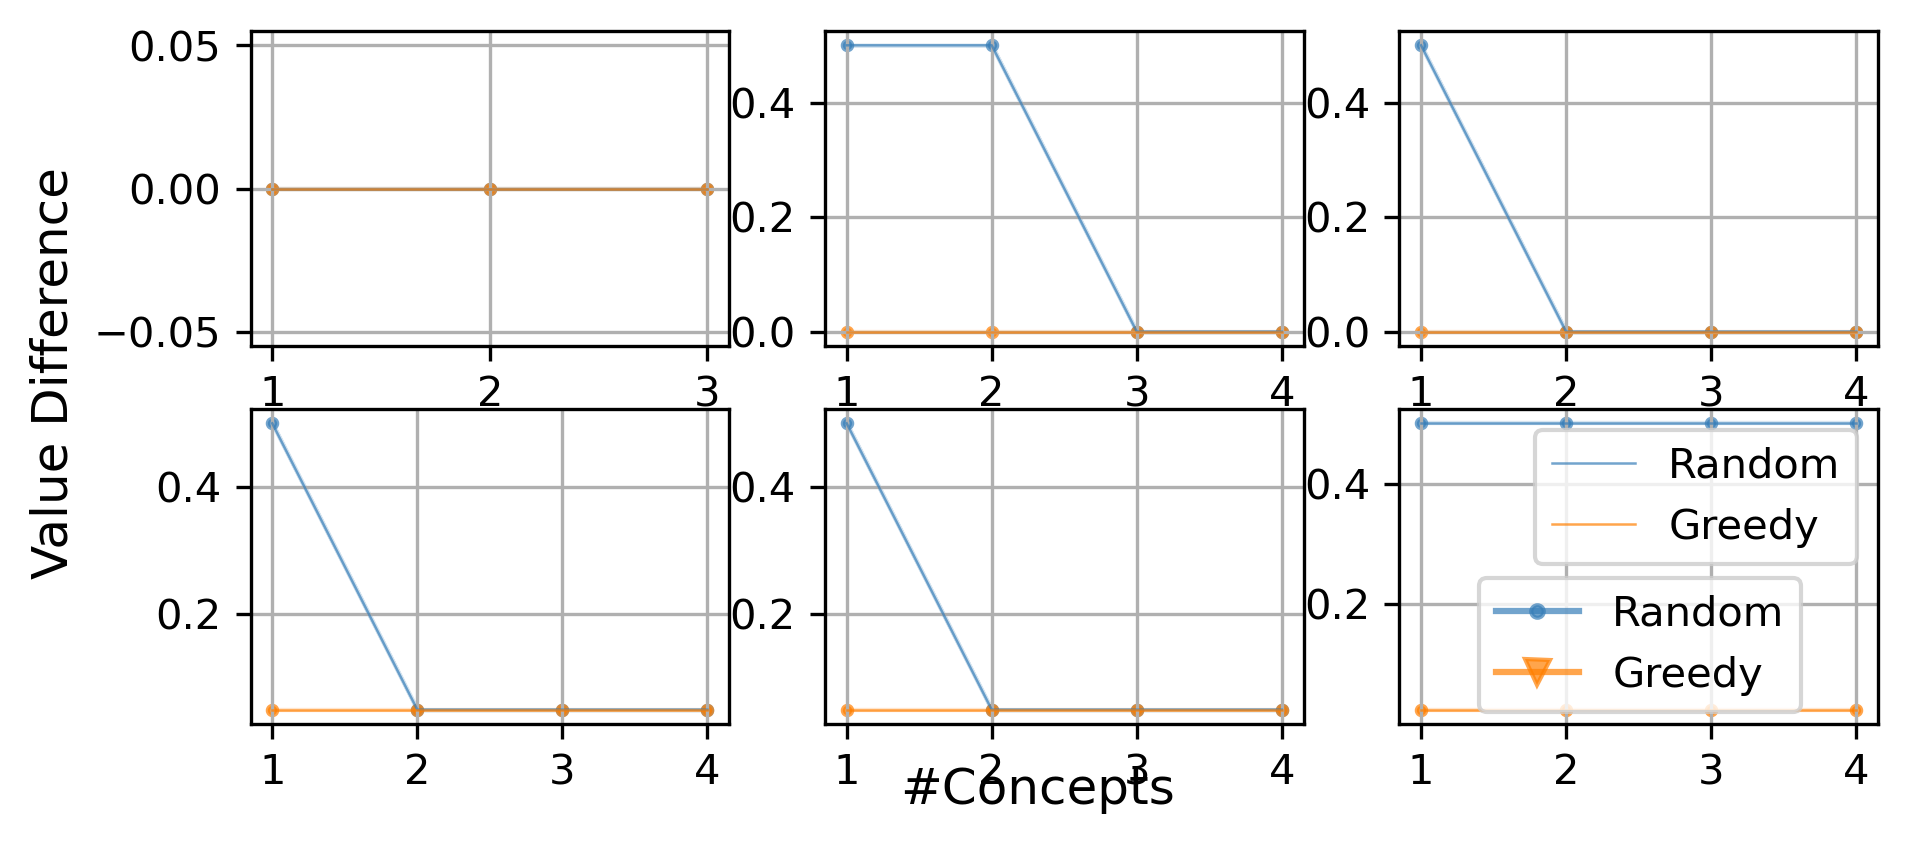

In [22]:
plot_dimensions = (2,3)
x_labels = [["","",""],["","",""]]
y_labels = [["","",""],["","",""]]
sup_y_label = "Value Difference"
sup_x_label = "#Concepts"
overall_format = {'figsize':(7,3),
    'style_size': style_size,
    'x_ticks': [[[[0,1,2,3],[1,2,3,4]] for i in range(3)] for j in range(2)],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label,sup_x_label=sup_x_label)
line_format = {'color_palette': 'six_color', 'linewidth': 10}
scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

for i in range(2):
    for j in range(3):
        
        plot_line(ax[i][j],[list(range(len(value_difference[method][i*3+j]))) for method in ['random','greedy']],[value_difference[method][i*3+j] for method in ['random','greedy']],[confidences_by_node[method][i*3+j] for method in ['random','greedy']],['Random','Greedy'],line_format)
        plot_scatter(ax[i][j],[list(range(len(value_difference[method][i*3+j]))) for method in ['random','greedy']],[value_difference[method][i*3+j] for method in ['random','greedy']],line_format)

legend_format = {'style_size': style_size,'type': 'is_global', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
plt.legend()
fig.savefig("../../results/figures/value_differences_tree.pdf",dpi=300, bbox_inches='tight')

### Concept Error

In [23]:
environment_nodes = [4,8,16]
fixed_accuracy = [0.1,0.25,0.5,0.75,0.9,0.99]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'cycle', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for acc in fixed_accuracy:
        baseline_params['cbm_accuracy_by_concept'] = [acc for i in range(n-1)]
        baseline_params['num_concepts_selected'] = 0
        results = get_results_matching_parameters("synthetic","",baseline_params)
        predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

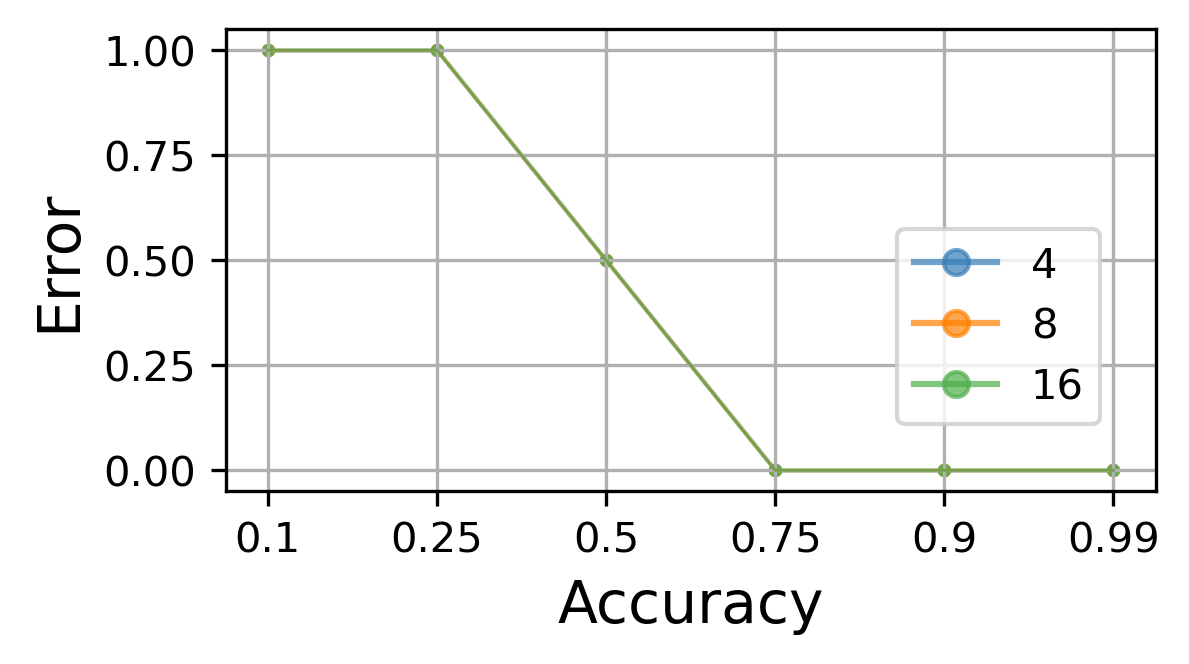

In [24]:
plot_dimensions = (1,1)
x_labels = [["Accuracy"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(fixed_accuracy))),fixed_accuracy]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/uncertainty_cycle.pdf",dpi=300, bbox_inches='tight')

In [25]:
environment_nodes = [15,127]
fixed_accuracy = [0.1,0.25,0.5,0.75,0.9,0.99]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'tree', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42, 'reward_error': 0, 'transition_error': 0, 'human_reliance_by_concept': None}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for acc in fixed_accuracy:
        baseline_params['cbm_accuracy_by_concept'] = [acc for i in range(int(np.log2(n+1))+1)]
        baseline_params['num_concepts_selected'] = 0
        results = get_results_matching_parameters("synthetic","",baseline_params)
        predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

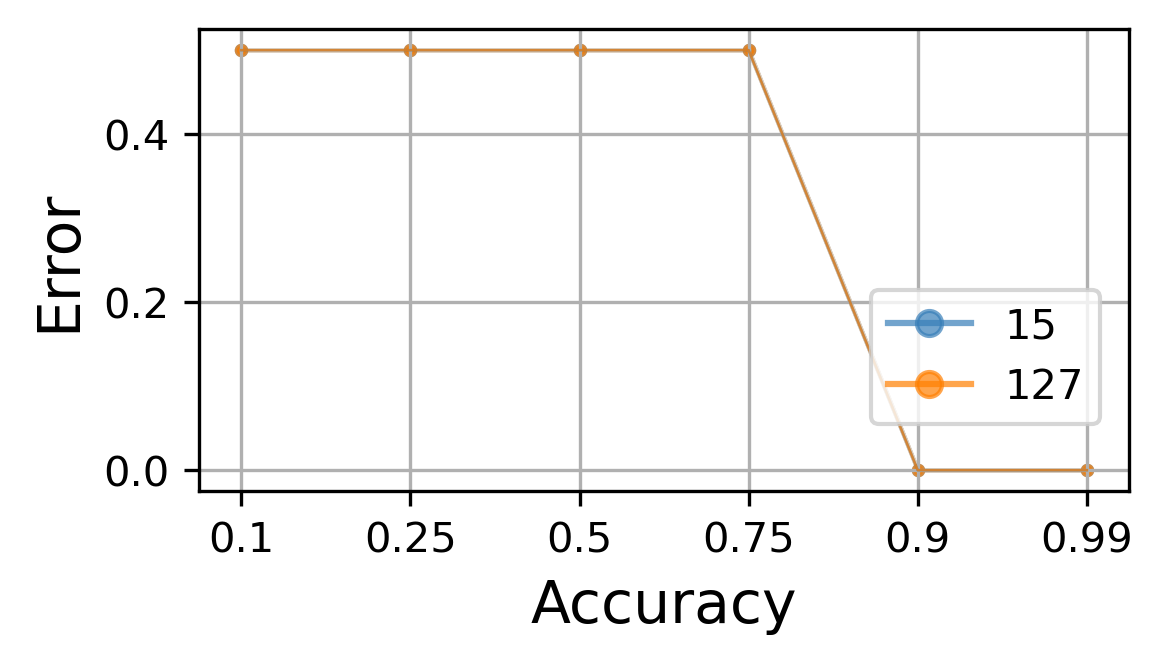

In [26]:
plot_dimensions = (1,1)
x_labels = [["Accuracy"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(fixed_accuracy))),fixed_accuracy]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/uncertainty_tree.pdf",dpi=300, bbox_inches='tight')

In [27]:
human_accuracy_by_concept = [0.9,0.9,0.9]
human_reliance_by_concept = [0.75,0.75,0.75]
baseline_params = {'environment_string': 'cycle', 'environment_nodes': 4,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
results = get_results_matching_parameters("synthetic","",baseline_params)
baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
baseline_params['show_baseline'] = False 

use_offline_concepts = []
select_new_concepts = []
for cbm_accuracy in [[0.5,1,1],[1,0.5,1],[1,1,0.5]]:
    baseline_params['cbm_accuracy_by_concept'] = cbm_accuracy
    baseline_params['num_concepts_selected'] = 0
    baseline_params['human_reliance_by_concept'] = [0.75,0.75,0.75]
    results = get_results_matching_parameters("synthetic","",baseline_params)

    predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    use_offline_concepts.append(diff)

    predicted_values = np.mean([r['uncertainty']['combined_value'] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    select_new_concepts.append(diff)

2 six_color 3


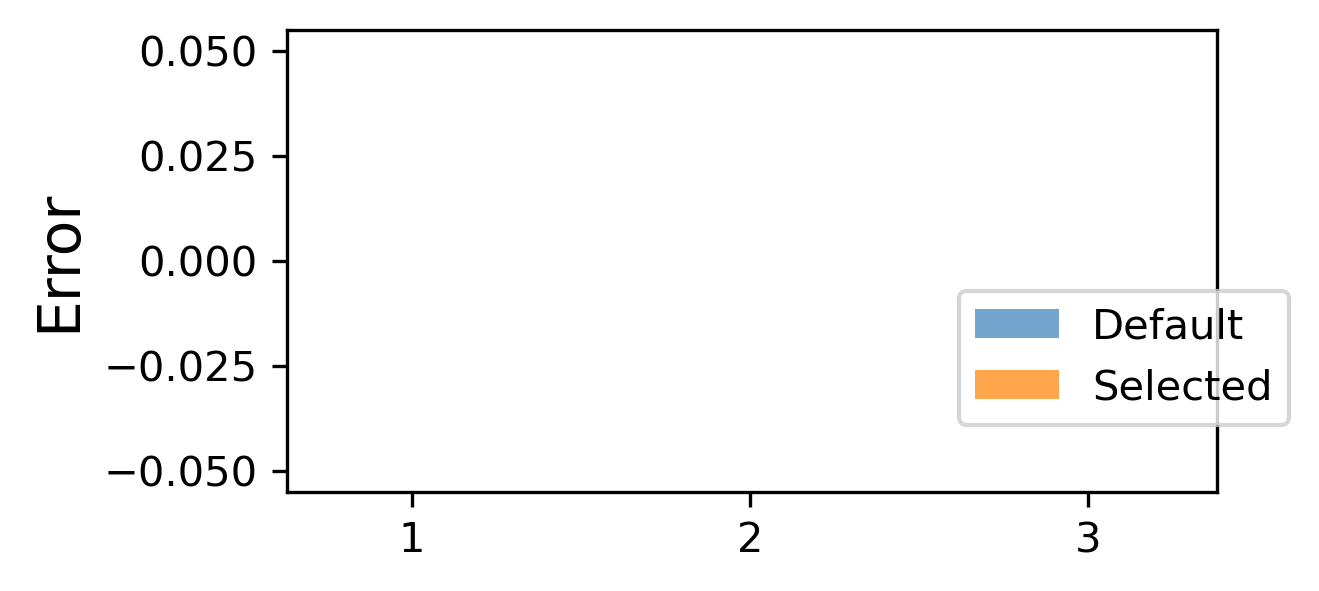

In [28]:
plot_dimensions = (1,1)
x_labels = [[""]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0.12,1.12,2.12],[1,2,3]]]],
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
y_values = np.array([use_offline_concepts,select_new_concepts]).T.flatten()
plot_bar(ax[0][0],[1,2,1,2,1,2],y_values,[0 for i in range(len(y_values))], {1: 'Default',2: 'Selected'},bar_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/human_centered_cycle.pdf",dpi=300, bbox_inches='tight')

In [29]:
human_accuracy_by_concept = [0.9,0.9,0.9,0.9,0.9]
human_reliance_by_concept = [0.75,0.75,0.75,0.75,0.75]
baseline_params = {'environment_string': 'tree', 'environment_nodes': 15,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
results = get_results_matching_parameters("synthetic","",baseline_params)
baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
baseline_params['show_baseline'] = False 

use_offline_concepts = []
less_human_reliance = []
select_new_concepts = []
for cbm_accuracy in [[0.5,1,1,1,1],[1,0.5,1,1,1],[1,1,0.5,1,1],[1,1,1,0.5,1],[1,1,1,1,0.5]]:
    baseline_params['cbm_accuracy_by_concept'] = cbm_accuracy
    baseline_params['num_concepts_selected'] = 0
    baseline_params['human_reliance_by_concept'] = [0.75,0.75,0.75,0.75,0.75]
    results = get_results_matching_parameters("synthetic","",baseline_params)
    predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    use_offline_concepts.append(diff)

    predicted_values = np.mean([r['uncertainty']['combined_value'] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    select_new_concepts.append(diff)

2 six_color 5


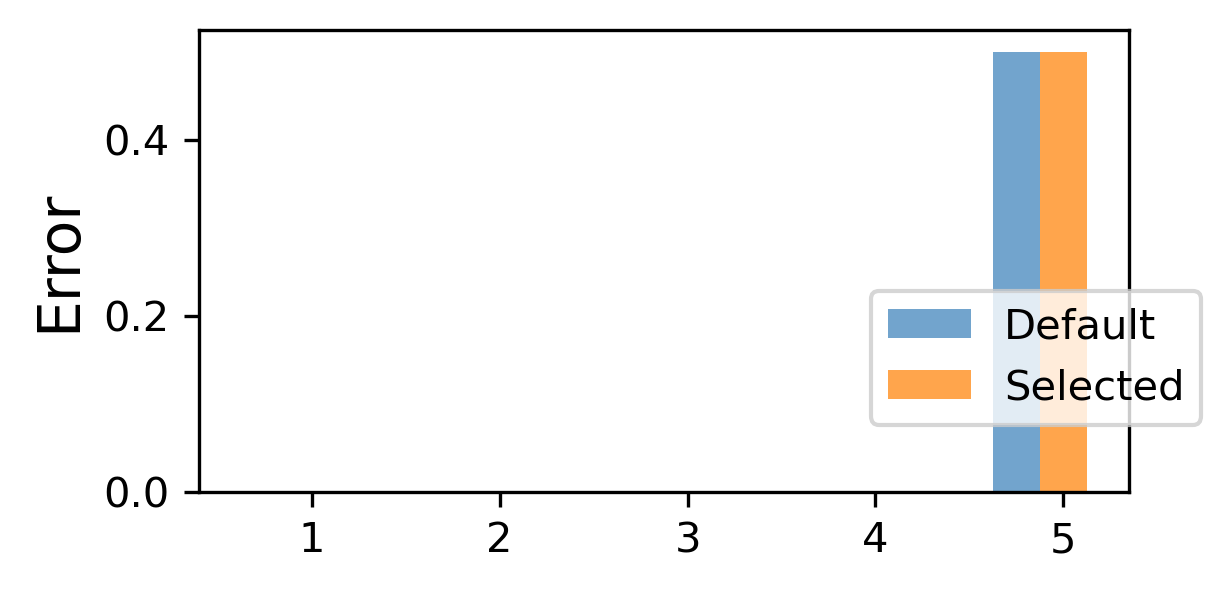

In [30]:
plot_dimensions = (1,1)
x_labels = [[""]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0.25,1.25,2.25,3.25,4.25],[1,2,3,4,5]]]],
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
y_values = np.array([use_offline_concepts,select_new_concepts]).T.flatten()
plot_bar(ax[0][0],[1,2,1,2,1,2,1,2,1,2],y_values,[0 for i in range(len(y_values))], {1: 'Default',2: 'Selected'},bar_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/human_centered_tree_2.pdf",dpi=300, bbox_inches='tight')

In [31]:
human_accuracy_by_concept = [0.9,0.9,0.9]
cbm_accuracy = [0.5,0.5,0.5,0.5,0.5]
baseline_params = {'environment_string': 'cycle', 'environment_nodes': 4,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
results = get_results_matching_parameters("synthetic","",baseline_params)
baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
baseline_params['show_baseline'] = False 
baseline_params['cbm_accuracy_by_concept'] = cbm_accuracy

use_offline_concepts = []
select_new_concepts = []
for human_rel in [0.1,0.25,0.5,0.75,0.9] :
    baseline_params['num_concepts_selected'] = 0
    baseline_params['human_reliance_by_concept'] = [human_rel,human_rel,human_rel]
    results = get_results_matching_parameters("synthetic","",baseline_params)
    predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    use_offline_concepts.append(diff)
    predicted_values = np.mean([r['uncertainty']['combined_value'] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    select_new_concepts.append(diff)

2 six_color 5


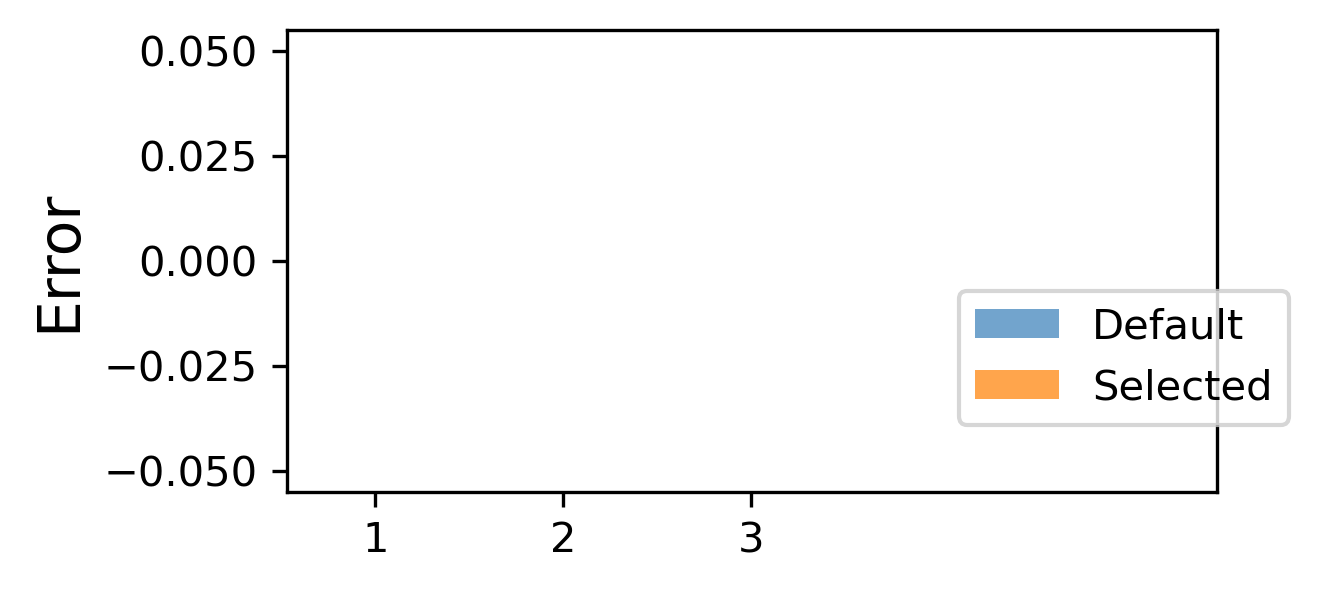

In [32]:
plot_dimensions = (1,1)
x_labels = [[""]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0.12,1.12,2.12],[1,2,3]]]],
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

x_values = []
for i in range(len(use_offline_concepts)):
    x_values += [1,2]

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
y_values = np.array([use_offline_concepts,select_new_concepts]).T.flatten()
plot_bar(ax[0][0],x_values,y_values,[0 for i in range(len(y_values))], {1: 'Default',2: 'Selected'},bar_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/human_centered_cycle.pdf",dpi=300, bbox_inches='tight')

In [33]:
human_accuracy_by_concept = [0.9,0.9,0.9,0.9,0.9]
cbm_accuracy = [0.5,0.5,0.5,0.5,0.5]
baseline_params = {'environment_string': 'tree', 'environment_nodes': 15,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
results = get_results_matching_parameters("synthetic","",baseline_params)
baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
baseline_params['show_baseline'] = False 
baseline_params['cbm_accuracy_by_concept'] = cbm_accuracy

use_offline_concepts = []
select_new_concepts = []
for human_rel in [0.1,0.25,0.5,0.75,0.9] :
    baseline_params['num_concepts_selected'] = 0
    baseline_params['human_reliance_by_concept'] = [human_rel,human_rel,human_rel,human_rel,human_rel]
    results = get_results_matching_parameters("synthetic","",baseline_params)
    predicted_values = np.mean([r['uncertainty']['values'][1] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    use_offline_concepts.append(diff)

    predicted_values = np.mean([r['uncertainty']['combined_value'] for r in results],axis=0)
    diff = np.max(np.abs(predicted_values-baseline_values))
    select_new_concepts.append(diff)

2 six_color 5


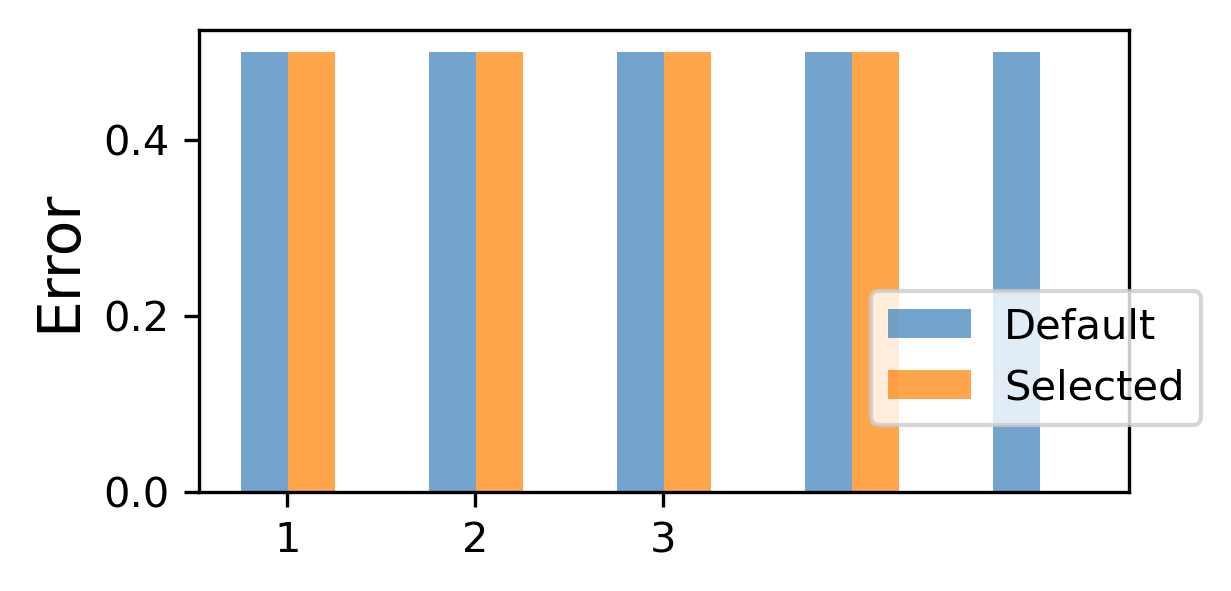

In [34]:
plot_dimensions = (1,1)
x_labels = [[""]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[[0.12,1.12,2.12],[1,2,3]]]],
    'has_grid': False, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

x_values = []
for i in range(len(use_offline_concepts)):
    x_values += [1,2]

bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
y_values = np.array([use_offline_concepts,select_new_concepts]).T.flatten()
plot_bar(ax[0][0],x_values,y_values,[0 for i in range(len(y_values))], {1: 'Default',2: 'Selected'},bar_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1),'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)
fig.savefig("../../results/figures/tree_human_reliance.pdf",dpi=300, bbox_inches='tight')

In [35]:
environment_nodes = [4]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'cycle', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = True 

    all_values = []

    for error in reward_error:
        baseline_params['reward_error'] = error 
        baseline_params['num_concepts_selected'] = 3
        results = get_results_matching_parameters("synthetic","",baseline_params)
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

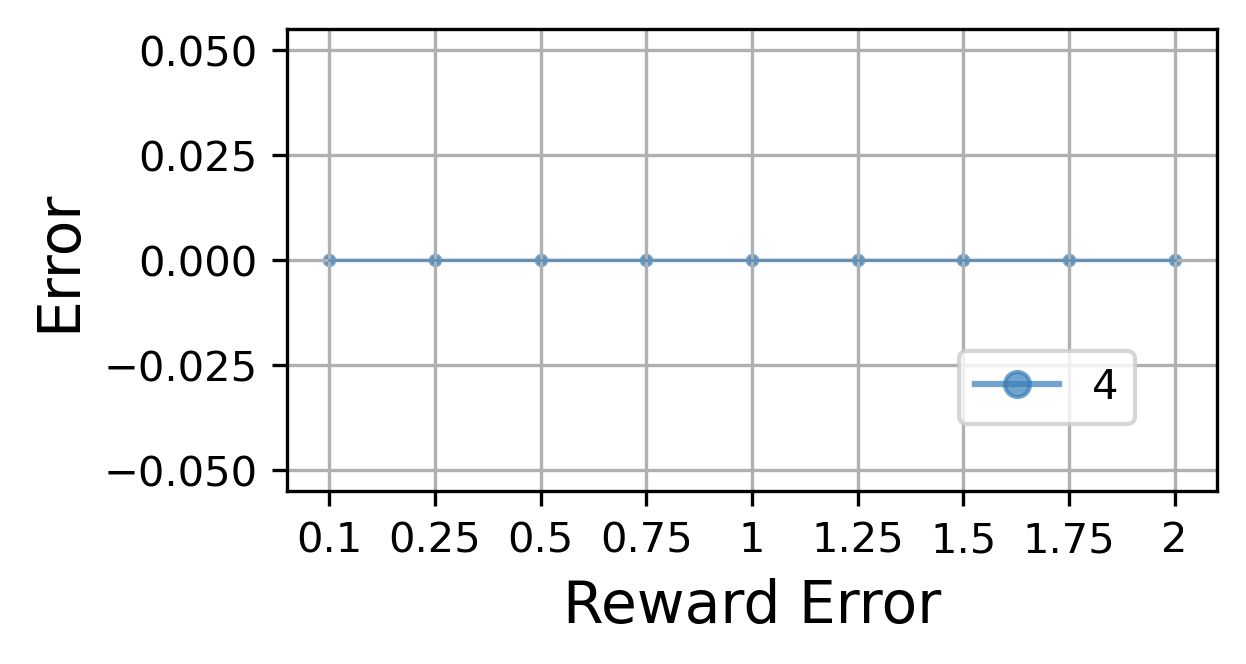

In [36]:
plot_dimensions = (1,1)
x_labels = [["Reward Error"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/reward_error_cycle.pdf",dpi=300, bbox_inches='tight')

In [37]:
environment_nodes = [4]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'cycle', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for error in reward_error:
        baseline_params['transition_error'] = error 
        baseline_params['num_concepts_selected'] = 3
        results = get_results_matching_parameters("synthetic","",baseline_params)
        
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

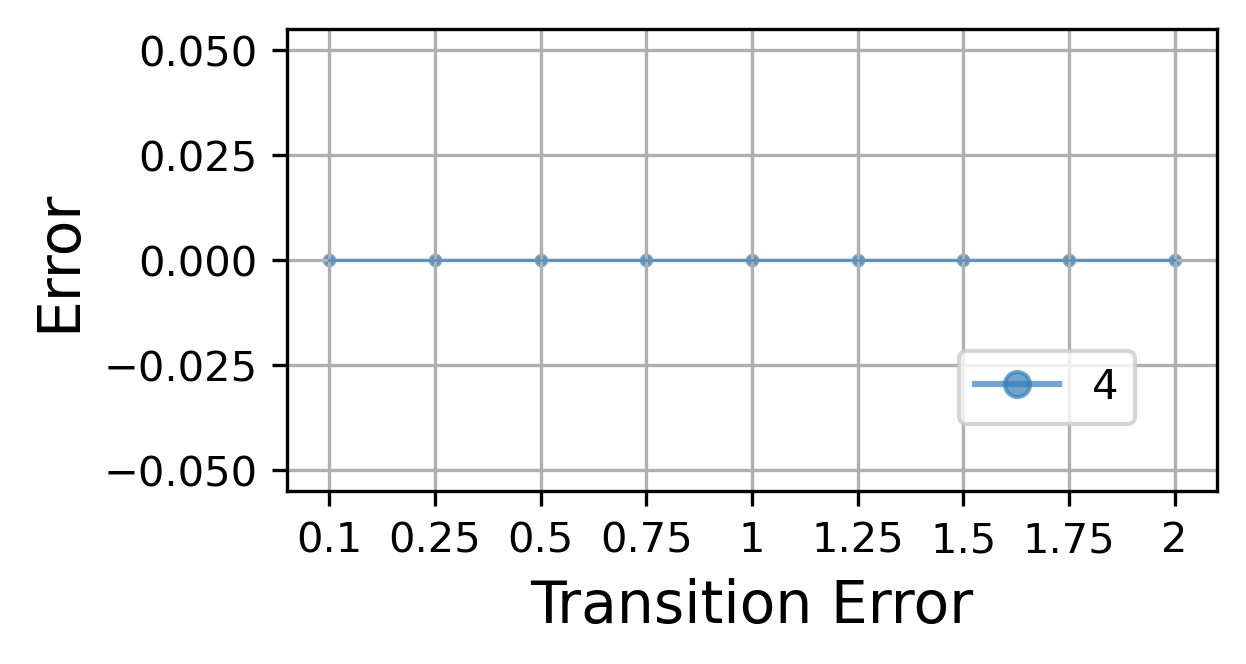

In [38]:
plot_dimensions = (1,1)
x_labels = [["Transition Error"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/reward_error_cycle.pdf",dpi=300, bbox_inches='tight')

In [39]:
environment_nodes = [15,127]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'tree', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for error in reward_error:
        baseline_params['reward_error'] = error 
        baseline_params['num_concepts_selected'] = 4
        results = get_results_matching_parameters("synthetic","",baseline_params)
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

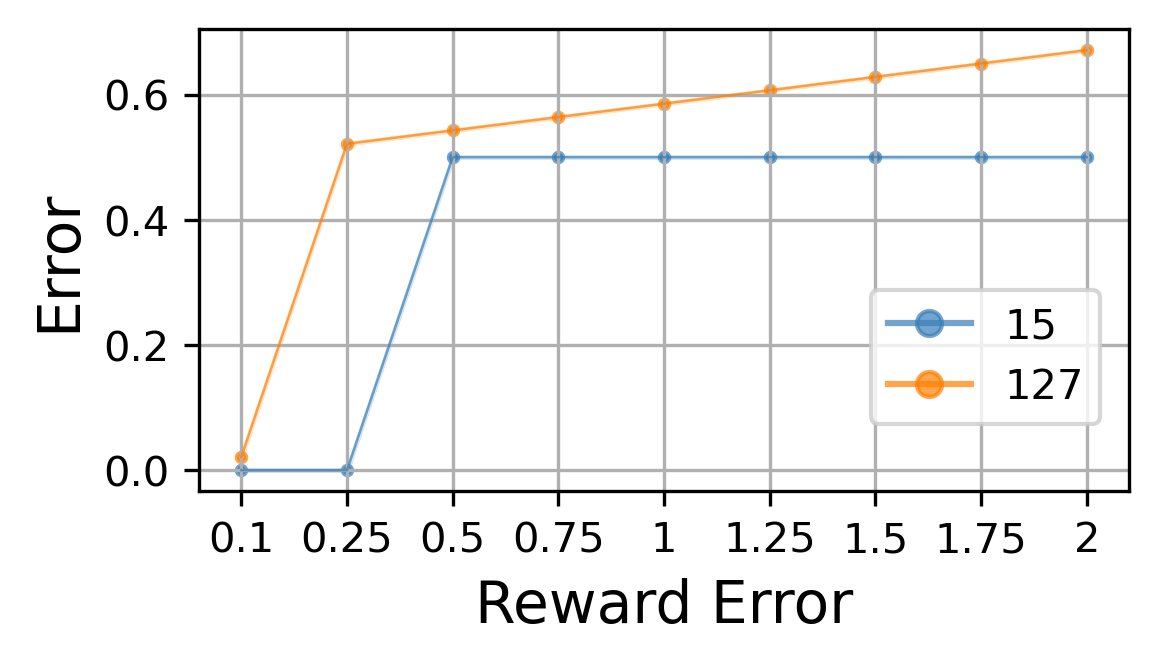

In [40]:
plot_dimensions = (1,1)
x_labels = [["Reward Error"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/reward_error_nodes_tree.pdf",dpi=300, bbox_inches='tight')

In [41]:
environment_nodes = [15,127]
reward_error = [0.1,0.25,0.5,0.75,1,1.25,1.5,1.75,2]

performance_gap = []

for n in environment_nodes:
    baseline_params = {'environment_string': 'tree', 'environment_nodes': n,'show_baseline': True, 'num_concepts_selected': 4, 'seed': 42}
    results = get_results_matching_parameters("synthetic","",baseline_params)
    baseline_values = np.mean([r['baseline']['values'][1] for r in results],axis=0)
    
    baseline_params['show_baseline'] = False 

    all_values = []

    for error in reward_error:
        baseline_params['transition_error'] = error 
        baseline_params['num_concepts_selected'] = 4
        results = get_results_matching_parameters("synthetic","",baseline_params)
        predicted_values = np.mean([r['greedy_selection']['values'][0] for r in results],axis=0)
        diff = np.max(np.abs(predicted_values-baseline_values))
        all_values.append(diff)
    performance_gap.append(all_values)

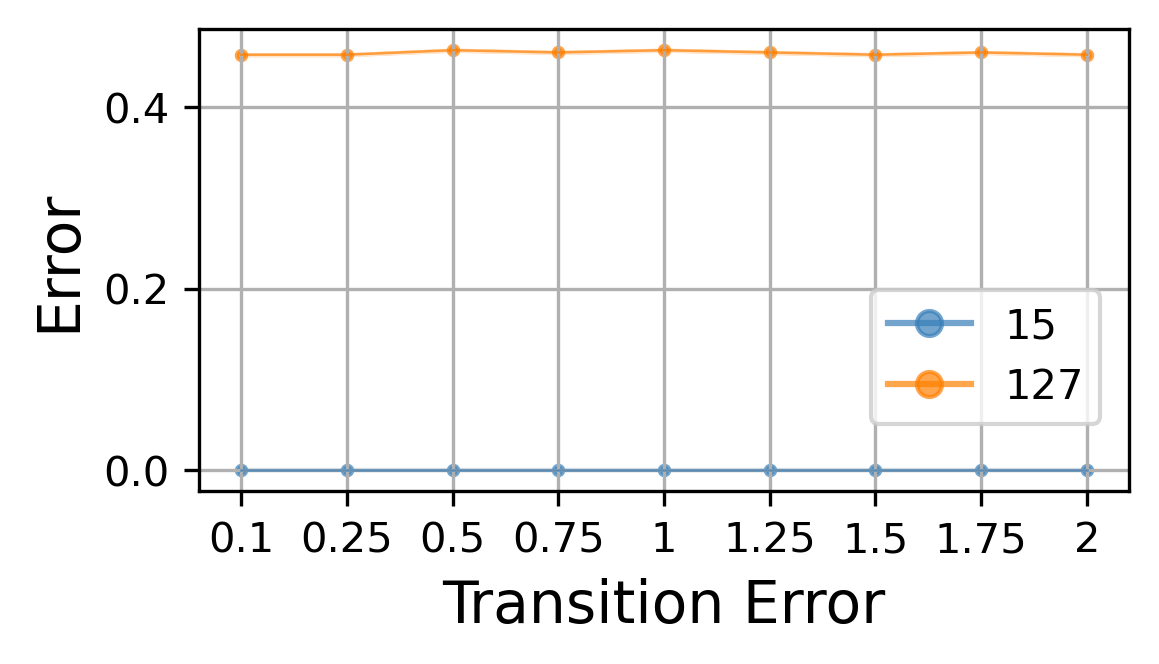

In [42]:
plot_dimensions = (1,1)
x_labels = [["Transition Error"]]
y_labels = [["Error"]]
sup_y_label = ""
overall_format = {'figsize':(4,2),
    'style_size': style_size,
    'x_ticks': [[[list(range(len(reward_error))),reward_error]]],
    'has_grid': True, 
}

fig,ax = create_axes(plot_dimensions,overall_format,x_labels=x_labels,y_labels=y_labels,sup_y_label=sup_y_label)

line_format = {'color_palette': 'six_color', 'linewidth': 10}

plot_line(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,[[0 for i in range(len(performance_gap[i]))] for i in range(len(performance_gap))],environment_nodes,line_format)

scatter_format = {'color_palette': 'six_color', 'size': 5, 'linewidth': 10}

plot_scatter(ax[0][0],[list(range(len(performance_gap[i]))) for i in range(len(performance_gap))],performance_gap,line_format)

legend_format = {'style_size': style_size,'type': 'is_local', 'loc': 'lower left', 'ncol': 1, 'bbox_to_anchor': (0.7,0.1), 'show_point': True, 'fontsize': 14}
create_legend(fig,ax,plot_dimensions,legend_format)

fig.savefig("../../results/figures/transition_error.pdf",dpi=300, bbox_inches='tight')